In [14]:
import pandas as pd
import numpy as np
import re
import contractions
from pathlib import Path
import matplotlib.pyplot as plt

In [15]:
# 1) LOAD DATA
INPUT_FILE = "../data/MCRA Survey.csv"
OUTPUT_DIR = Path("cleansed_data")
OUTPUT_DIR.mkdir(exist_ok=True)

df = pd.read_csv(INPUT_FILE)

In [16]:
print("Shape:", df.shape)
print("\nColumns:")
for i, col in enumerate(df.columns):
    print(f"{i}: {col}")

Shape: (80, 20)

Columns:
0: Username
1: Timestamp
2: What is your current year of study?
3: Have you decided on your specialization track?
4: To what extent do you agree:
"I understand what people in each track actually do in real-world roles (e.g. projects, internships, job scope).

(1 = Strongly Disagree; 2 = Disagree; 3 = Neutral; 4 = Agree; 5 = Strongly Agree)
5: Before choosing your track, did you feel like you had enough exposure to real-world examples?
6: Which of the following sources do you rely on MOST to understand different tracks? (Select up to 2)
7: To what extent do you agree:
“The guidance I received so far when choosing my track is tailored to my strengths and interests.”

(1 = Strongly Disagree; 2 = Disagree; 3 = Neutral; 4 = Agree; 5 = Strongly Agree)
8: How helpful do you find the current guidance provided by SCIS (e.g. portals, talks, advisors)?

(1 = Not Helpful; 2 = Slightly Helpful; 3 = Moderately Helpful; 4 = Helpful; 5 = Very Helpful)
9: What is your biggest 

In [17]:
# 2) RENAME COLUMNS
df.columns = [
    "username",
    "timestamp",
    "year",
    "track_decided",
    "understand_roles",
    "realworld_exposure",
    "info_sources_undecided",
    "guidance_tailored",
    "guidance_helpful",
    "biggest_challenge",
    "decision_gap_undecided",
    "simulation_useful_now",
    "recommendation_useful_now",
    "process_clear",
    "experience",
    "info_sources_decided",
    "decision_gap_decided",
    "simulation_useful_past",
    "recommendation_useful_past",
    "realworld_understanding"
]

df["timestamp"] = pd.to_datetime(
    df["timestamp"].str.replace(" GMT+8", "", regex=False),
    format="%Y/%m/%d %I:%M:%S %p"
)

df["timestamp"].head()

0   2026-04-03 11:45:44
1   2026-04-03 11:46:53
2   2026-04-03 11:50:16
3   2026-04-03 11:51:37
4   2026-04-03 11:53:57
Name: timestamp, dtype: datetime64[ns]

In [18]:
# 3) HELPER FUNCTIONS
def clean_cell_basic(x):
    """
    Basic cleaning for predefined fields:
    - keep values as they are
    - only strip leading/trailing whitespace
    - collapse repeated spaces/newlines
    """
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x == "":
        return np.nan
    x = re.sub(r"\s+", " ", x).strip()
    return x

def clean_open_ended_text(x):
    """
    Slightly stronger cleaning only for the open-ended response.
    Keeps meaning, expands contractions safely.
    """
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x == "":
        return np.nan
    x = contractions.fix(x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

def split_sources(x):
    """
    Source responses are multi-select and in your file are separated by semicolons.
    Important: do NOT split on commas because commas appear inside
    'School platforms (Oasis, website)'.
    """
    if pd.isna(x):
        return []
    parts = [part.strip() for part in str(x).split(";")]
    return [part for part in parts if part]

In [19]:
# 4) BASIC CLEANING
# Keep timestamp as text so no parsing issues
basic_text_cols = [
    "username",
    "timestamp",
    "year",
    "track_decided",
    "realworld_exposure",
    "info_sources_undecided",
    "biggest_challenge",
    "decision_gap_undecided",
    "info_sources_decided",
    "decision_gap_decided"
]

for col in basic_text_cols:
    df[col] = df[col].apply(clean_cell_basic)

# only the open-ended question gets stronger text cleaning
df["experience"] = df["experience"].apply(clean_open_ended_text)


In [20]:
# 5) CLEAN TRACK_DECIDED + CREATE USER_GROUP

df["user_group"] = df["track_decided"].map({
    "Yes": "decided",
    "No": "undecided"
})

In [21]:
# 6) CONVERT RATING COLUMNS TO NUMERIC
score_cols = [
    "understand_roles",
    "guidance_tailored",
    "guidance_helpful",
    "simulation_useful_now",
    "recommendation_useful_now",
    "process_clear",
    "simulation_useful_past",
    "recommendation_useful_past",
    "realworld_understanding"
]

for col in score_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [22]:
# 7) COMBINE DUPLICATED BRANCH FIELDS
# Undecided branch + decided branch combined into single analysis columns

df["info_sources"] = df["info_sources_undecided"].combine_first(df["info_sources_decided"])
df["decision_gap"] = df["decision_gap_undecided"].combine_first(df["decision_gap_decided"])
df["simulation_useful"] = df["simulation_useful_now"].combine_first(df["simulation_useful_past"])
df["recommendation_useful"] = df["recommendation_useful_now"].combine_first(df["recommendation_useful_past"])

# clean combined text columns again lightly
combined_text_cols = ["info_sources", "decision_gap"]
for col in combined_text_cols:
    df[col] = df[col].apply(clean_cell_basic)

In [23]:
# 8) MAIN DATASET FOR TABLEAU

main_df = df[[
    "username",
    "timestamp",
    "year",
    "track_decided",
    "user_group",
    "understand_roles",
    "realworld_exposure",
    "guidance_tailored",
    "guidance_helpful",
    "biggest_challenge",
    "decision_gap",
    "simulation_useful",
    "recommendation_useful",
    "process_clear",
    "experience",
    "realworld_understanding",
    "info_sources"
]].copy()


In [24]:
import re

import pandas as pd
 
def pre_process(text, stopwords=None):

    if pd.isna(text):

        return ""
 
    text = str(text).lower()
 
    # normalize curly apostrophes

    text = text.replace("’", "'").replace("‘", "'")
 
    # DO NOT expand contractions
 
    # remove html

    text = re.sub(r"<.*?>", " ", text)
 
    # remove digits

    text = re.sub(r"\d+", " ", text)
 
    # KEEP apostrophes here

    text = re.sub(r"[^a-zA-Z\s']", " ", text)
 
    # remove extra spaces

    text = re.sub(r"\s+", " ", text).strip()
 
    # remove stopwords (but DO NOT remove "not" logic equivalents)

    if stopwords:

        stopwords = stopwords - {"not", "no", "nor"}  # still safe

        text = " ".join([word for word in text.split() if word not in stopwords])
 
    return text

def get_stop_words(stop_file_path):
    with open(stop_file_path, "r", encoding="utf-8") as f:
        stopwords = {line.strip().lower() for line in f if line.strip()}
    return stopwords
 
stopwords = get_stop_words("stopwords.txt")
 
# IMPORTANT: keep negation words because they carry meaning
stopwords = stopwords - {"not", "no", "nor"}

main_df["experience_clean"] = df["experience"].apply(lambda x: pre_process(x, stopwords))

In [25]:
# 10) EXPORT FILES
main_df.to_excel(OUTPUT_DIR / "mcra_cleaned_main.xlsx", index=False)

print("Done.")
print(f"Saved: {OUTPUT_DIR / 'mcra_cleaned_main.xlsx'}")


Done.
Saved: cleansed_data/mcra_cleaned_main.xlsx


[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/xiangyingg/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/xiangyingg/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/xiangyingg/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


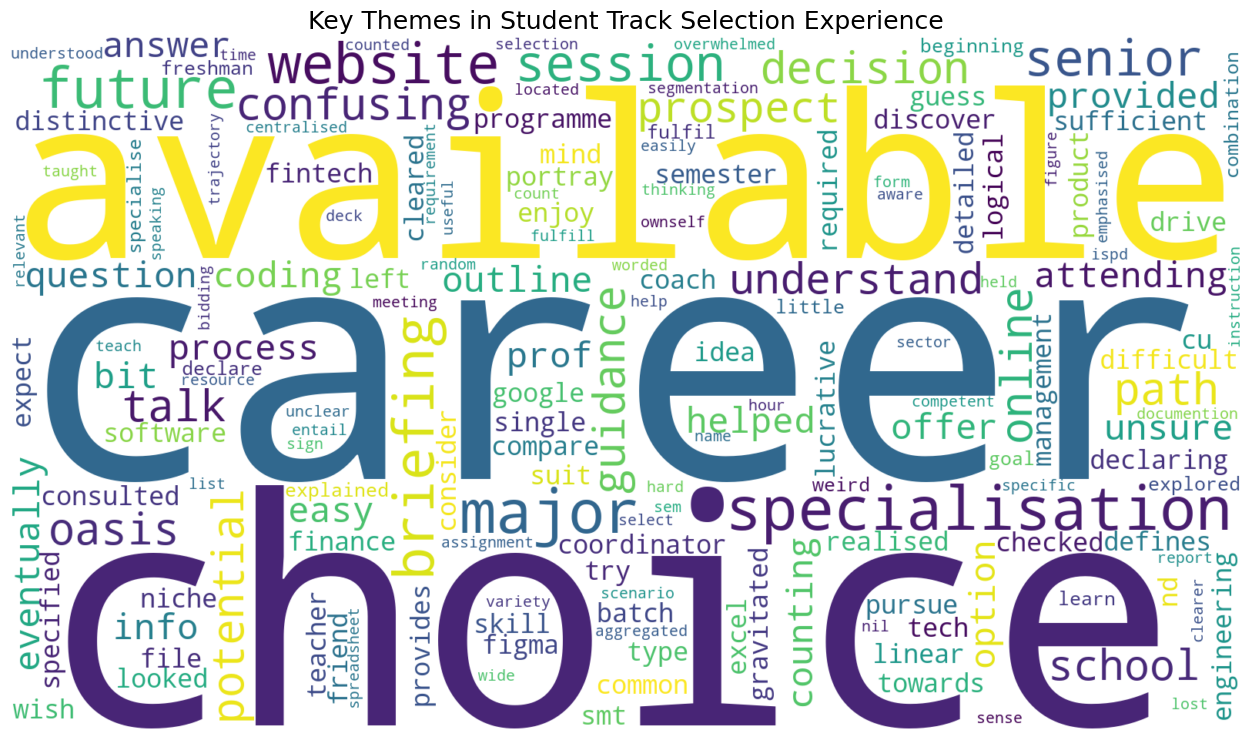

In [26]:
# IMPORTS
from wordcloud import WordCloud
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

# =========================
# DOWNLOAD (run once)
# =========================
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("stopwords")

# =========================
# SETUP
# =========================
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

# remove domain-specific noise
CUSTOM_REMOVE = {
    "track", "tracks", "module", "modules", "information",
    "course", "courses", "smu", "mods", "scis", "bro"
}

# remove generic useless words
EXTRA_STOPWORDS = {
    "able", "start", "double", "feel", "exactly", "also",
    "etc", "really", "thing", "lot", "make", "made"
}

# normalize important words (THIS IS KEY 🔥)
NORMALIZE_MAP = {
    "confuse": "confusing",
    "confused": "confusing",
    "confusing": "confusing",

    "decide": "decision",
    "deciding": "decision",
    "decision": "decision",

    "choose": "choice",
    "choosing": "choice",
    "choice": "choice",

    "guide": "guidance",
    "guided": "guidance",
    "guiding": "guidance",
    "guidance": "guidance",

    "career": "career",
    "job": "career"
}

# CLEANING FUNCTION
def clean_for_wordcloud(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()

    # keep only letters
    text = re.sub(r"[^a-z\s]", " ", text)

    tokens = text.split()
    cleaned_tokens = []

    for token in tokens:

        if token in stop_words or token in EXTRA_STOPWORDS or token in CUSTOM_REMOVE:
            continue

        # lemmatize
        lemma = lemmatizer.lemmatize(token)

        # normalize key words
        normalized = NORMALIZE_MAP.get(lemma, lemma)

        if normalized in stop_words or normalized in EXTRA_STOPWORDS or normalized in CUSTOM_REMOVE:
            continue

        cleaned_tokens.append(normalized)

    return " ".join(cleaned_tokens)

# APPLY CLEANING
main_df["experience_clean_wc"] = main_df["experience_clean"].apply(clean_for_wordcloud)

# COMBINE TEXT
text_for_wc = " ".join(main_df["experience_clean_wc"].fillna(""))

# =========================
# GENERATE WORD CLOUD
# =========================
wordcloud = WordCloud(
    width=1600,
    height=900,
    background_color="white",
    collocations=False
).generate(text_for_wc)

# DISPLAY
plt.figure(figsize=(16, 9))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Key Themes in Student Track Selection Experience", fontsize=18)
plt.show()